In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from langdetect import detect
import re
import emoji
from pathlib import Path
import os

In [ ]:
# ================= PROJECT ROOT & DATA PATHS =================
try:
    PROJECT_ROOT = Path(__file__).resolve().parent
except NameError:
    PROJECT_ROOT = Path.cwd()  # fallback if running interactively

DEFAULT_DATA_DIR = Path(r"C:/Users/DELL/Documents/project_data/output")
DATA_DIR = Path(os.getenv("DATA_DIR", DEFAULT_DATA_DIR))

POSTS_PATH = DATA_DIR / "safaricom_posts.csv"
COMMENTS_PATH = DATA_DIR / "safaricom_comments22.csv"

# ================= FILE EXISTENCE CHECK =================
print("Using DATA_DIR:", DATA_DIR)
if not POSTS_PATH.exists():
    raise FileNotFoundError(f"Posts file not found: {POSTS_PATH}")
if not COMMENTS_PATH.exists():
    raise FileNotFoundError(f"Comments file not found: {COMMENTS_PATH}")

# ================= LOAD CSVs =================
posts = pd.read_csv(POSTS_PATH)
comment = pd.read_csv(COMMENTS_PATH)


comments = comment[[ 'text']].dropna()

#================== DATA INSPECTION =================
print("\n=== BEFORE PREPROCESSING ===")
print(f"Posts shape: {posts.shape}")
print(f"Comments shape: {comment.shape}")
print("\nPosts columns:", posts.columns.tolist())
print("Comments columns:", comment.columns.tolist())

print("\n------ For Sentiment Analysis ------")
print(f"Comments shape: {comments.shape}")


Using DATA_DIR: C:\Users\DELL\Documents\project_data\output

=== BEFORE PREPROCESSING ===
Posts shape: (1948, 11)
Comments shape: (286376, 5)

Posts columns: ['msg_id', 'date_utc', 'text', 'views', 'forwards', 'replies', 'has_media', 'media_type', 'sender_id', 'reply_to_msg_id', 'num_comments']
Comments columns: ['post_id', 'comment_id', 'date_utc', 'text', 'sender_id']

------ For Sentiment Analysis ------
Comments shape: (279536, 1)


In [ ]:
# ================= FILL MISSING VALUES =================

comments= comments.fillna('<deleted>')

In [40]:
comments.head()

,text
0,እካ ሰላምታ ....... በምንትያ\nበዳጣ .....ምናለ በዳጣ\nካስደሰኳ...
1,ሰላም Melak፣ 🎉ለተሳትፎዎ እናመሰግናለን! የእንካ ሰላምታ ጨዋታ ተጠና...
2,እንካ ሰላምታ.....በምንቲያ ?\nበ ገርጂ ...... ምን አለ በ ገርጂ...
3,እንኳን ደስ አሎት🎉! Haf ማን፣ በእንካ ሰላምታ በመግጠም ያሎትን ችሎታ...
4,እንኳን ደስ አሎት🎉! በእንካ ሰላምታ በመግጠም ያሎትን ችሎታ ስላሳዩ እና...


In [41]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    
    # 1. Remove URLs (links)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # 2. Remove mentions and hashtags (optional - keep if needed for analysis)
    text = re.sub(r'@\w+', '', text)  # remove @mentions
    # text = re.sub(r'#\w+', '', text)  # uncomment to remove hashtags
    
    # 4. Remove special characters and digits (keep only letters and spaces)
    text = re.sub(r'[^a-zA-Z\u1200-\u137F\s]', '', text)  # keeps Amharic and English
    
    # 5. Convert to lowercase (if English-heavy, but Amharic doesn't have case)
    text = text.lower()
    
    # 6. Remove extra whitespace
    text = ' '.join(text.split())
    
    return text

# Apply cleaning
comments['cleaned'] = comments['text'].apply(clean_text)

=== COMMENT TYPE DISTRIBUTION ===


,count,percentage
comment_type,,
Text only,203771,72.90
Text + Emoji,52974,18.95
Empty/Other,18820,6.73
Emoji only,3971,1.42


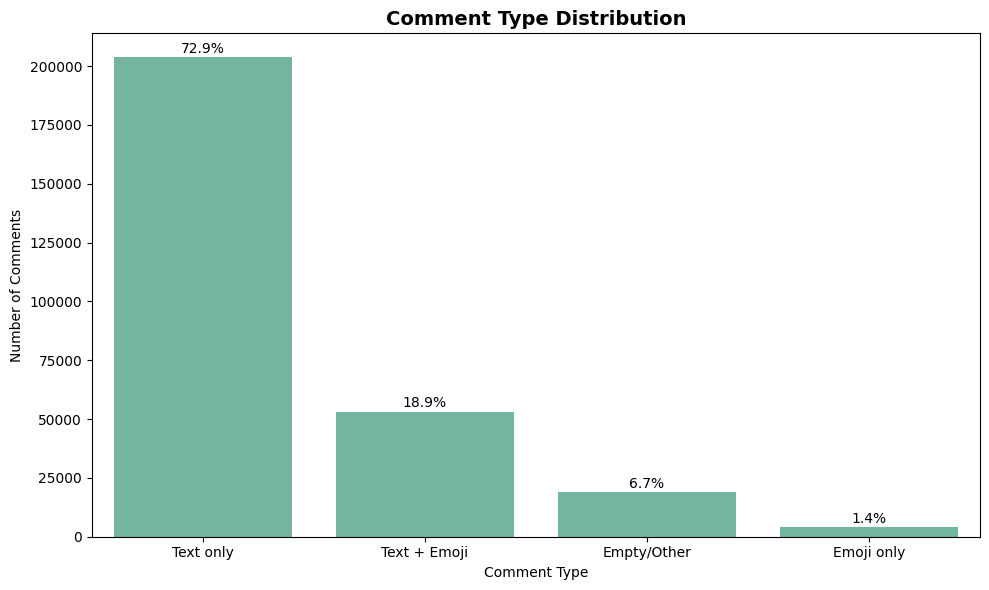

In [ ]:
# ===============================
# Robust Comment Type Detection
# ===============================

import pandas as pd
import re
import emoji
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------
# 1. Ensure 'cleaned_text' exists
# ------------------------------
if 'cleaned_text' not in comments.columns:
    comments['cleaned_text'] = comments['text'].astype(str).str.strip()

# ------------------------------
# 2. Regex for language detection
# ------------------------------
AMHARIC_RE = re.compile(r'[\u1200-\u137F]')
ENGLISH_RE = re.compile(r'[A-Za-z]')

def contains_emoji(text: str) -> bool:
    """Check if string contains at least one emoji (robust)."""
    return bool(emoji.emoji_list(text))  # returns list of emoji found

# ------------------------------
# 3. Classification function
# ------------------------------
def classify_comment_type(text: str) -> str:
    text = str(text).strip()
    
    if not text:
        return 'Empty/Other'
    
    has_amharic = bool(AMHARIC_RE.search(text))
    has_english = bool(ENGLISH_RE.search(text))
    has_text = has_amharic or has_english
    has_emoji = contains_emoji(text)
    
    if has_text and has_emoji:
        return 'Text + Emoji'
    elif has_text:
        return 'Text only'
    elif has_emoji:
        return 'Emoji only'
    else:
        return 'Empty/Other'

# ------------------------------
# 4. Apply classification
# ------------------------------
comments['comment_type'] = comments['cleaned_text'].apply(classify_comment_type)

# ------------------------------
# 5. Compute counts and percentages
# ------------------------------
comment_type_counts = comments['comment_type'].value_counts()
comment_type_percent = (comment_type_counts / len(comments) * 100).round(2)

summary_df = pd.DataFrame({
    'count': comment_type_counts,
    'percentage': comment_type_percent
}).sort_values('count', ascending=False)

print("=== COMMENT TYPE DISTRIBUTION ===")
display(summary_df)

# ------------------------------
# 6. Visualization (fixed warning)
# ------------------------------
plt.figure(figsize=(10, 6))

# Use color palette as list instead of 'palette' parameter
palette_colors = sns.color_palette('Set2', n_colors=len(summary_df))

sns.barplot(
    x=summary_df.index,
    y=summary_df['count'],
    color=palette_colors[0],  # uniform color
)

plt.title('Comment Type Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Comment Type')
plt.ylabel('Number of Comments')

# Annotate percentages on top of bars
for i, v in enumerate(summary_df['count']):
    pct = summary_df['percentage'].iloc[i]
    plt.text(i, v + max(summary_df['count']) * 0.01, f"{pct:.1f}%", 
             ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [43]:
# -----------------------------
# Show sample 'Empty/Other' comments
# -----------------------------
sample_empty = comments[comments['comment_type'] == 'Empty/Other']['text'].tail(10)

print("=== SAMPLE EMPTY/OTHER COMMENTS ===")
for i, txt in enumerate(sample_empty, 1):
    print(f"{i}. {txt}")

=== SAMPLE EMPTY/OTHER COMMENTS ===
1. 3,141
2. 2700
3. 3000
4. 300
5. 3000
6. 3000
7. 0722579432
8. 0722737398
9. 0723182506
10. 100%


In [36]:
import pandas as pd
import re
import emoji

# Assume 'comments' DataFrame already exists with 'text' column

# 1. Ensure cleaned_text
if 'cleaned_text' not in comments.columns:
    comments['cleaned_text'] = comments['text'].astype(str).str.strip()

# 2. Classify (same as your robust version)
AMHARIC_RE = re.compile(r'[\u1200-\u137F]')
ENGLISH_RE = re.compile(r'[A-Za-z]')

def contains_emoji(text: str) -> bool:
    return bool(emoji.emoji_list(text))

def classify_comment_type(text: str) -> str:
    text = str(text).strip()
    if not text:
        return 'Empty/Other'
    has_amharic = bool(AMHARIC_RE.search(text))
    has_english = bool(ENGLISH_RE.search(text))
    has_text = has_amharic or has_english
    has_emoji = contains_emoji(text)
    
    if has_text and has_emoji:
        return 'Text + Emoji'
    elif has_text:
        return 'Text only'
    elif has_emoji:
        return 'Emoji only'
    else:
        return 'Empty/Other'

comments['comment_type'] = comments['cleaned_text'].apply(classify_comment_type)

# Show before
print("=== BEFORE DROPPING ===")
print(comments['comment_type'].value_counts())

# 3. Process as requested
# Drop Empty/Other
comments = comments[comments['comment_type'] != 'Empty/Other'].copy()

# For Text + Emoji: remove emoji, keep text
def remove_emoji(text: str) -> str:
    return emoji.replace_emoji(text, replace="").strip()

comments.loc[comments['comment_type'] == 'Text + Emoji', 'model_text'] = \
    comments.loc[comments['comment_type'] == 'Text + Emoji', 'cleaned_text'].apply(remove_emoji)

# For Text only and Emoji only: keep original cleaned_text
comments.loc[comments['comment_type'] != 'Text + Emoji', 'model_text'] = \
    comments.loc[comments['comment_type'] != 'Text + Emoji', 'cleaned_text']

# Show after
print("\n=== AFTER PROCESSING ===")
print("Total comments kept:", len(comments))
print(comments['comment_type'].value_counts())
print("\nSample model_text:")

comments[['text', 'model_text']].head(10)

=== BEFORE DROPPING ===
comment_type
Text only      255535
Empty/Other     24001
Name: count, dtype: int64

=== AFTER PROCESSING ===
Total comments kept: 255535
comment_type
Text only    255535
Name: count, dtype: int64

Sample model_text:


,text,model_text
0,እካ ሰላምታ ....... በምንትያ\nበዳጣ .....ምናለ በዳጣ\nካስደሰኳ...,እካ ሰላምታ በምንትያ በዳጣ ምናለ በዳጣ ካስደሰኳቹ ሸልሙኝ ዳታ
1,ሰላም Melak፣ 🎉ለተሳትፎዎ እናመሰግናለን! የእንካ ሰላምታ ጨዋታ ተጠና...,ሰላም melak፣ ለተሳትፎዎ እናመሰግናለን የእንካ ሰላምታ ጨዋታ ተጠናቋል...
2,እንካ ሰላምታ.....በምንቲያ ?\nበ ገርጂ ...... ምን አለ በ ገርጂ...,እንካ ሰላምታበምንቲያ በ ገርጂ ምን አለ በ ገርጂ ምንድነው እንዲ መፈራራ...
3,እንኳን ደስ አሎት🎉! Haf ማን፣ በእንካ ሰላምታ በመግጠም ያሎትን ችሎታ...,እንኳን ደስ አሎት haf ማን፣ በእንካ ሰላምታ በመግጠም ያሎትን ችሎታ ስ...
4,እንኳን ደስ አሎት🎉! በእንካ ሰላምታ በመግጠም ያሎትን ችሎታ ስላሳዩ እና...,እንኳን ደስ አሎት በእንካ ሰላምታ በመግጠም ያሎትን ችሎታ ስላሳዩ እና ብ...
5,እንኳን ደስ አሎት🎉! Melek፣ በእንካ ሰላምታ በመግጠም ያሎትን ችሎታ ...,እንኳን ደስ አሎት melek፣ በእንካ ሰላምታ በመግጠም ያሎትን ችሎታ ስላ...
6,"Hi Abu, Currently, our M-Pesa app is accessibl...",hi abu currently our mpesa app is accessible o...
7,ሰላም Es፣ እኛ ካስቀመጥነው ዋጋ በላይ ከተጠየቁ እባክዎ ይህን ሊንክ @...,ሰላም es፣ እኛ ካስቀመጥነው ዋጋ በላይ ከተጠየቁ እባክዎ ይህን ሊንክ በ...
8,Please let me know how to download and use Sef...,please let me know how to download and use sef...
9,Er Friend ezih 3000 birr eyalun nw mnshe nw g...,er friend ezih birr eyalun nw mnshe nw gin


In [37]:
comments.head()

,text,cleaned_text,comment_type,model_text
0,እካ ሰላምታ ....... በምንትያ\nበዳጣ .....ምናለ በዳጣ\nካስደሰኳ...,እካ ሰላምታ በምንትያ በዳጣ ምናለ በዳጣ ካስደሰኳቹ ሸልሙኝ ዳታ,Text only,እካ ሰላምታ በምንትያ በዳጣ ምናለ በዳጣ ካስደሰኳቹ ሸልሙኝ ዳታ
1,ሰላም Melak፣ 🎉ለተሳትፎዎ እናመሰግናለን! የእንካ ሰላምታ ጨዋታ ተጠና...,ሰላም melak፣ ለተሳትፎዎ እናመሰግናለን የእንካ ሰላምታ ጨዋታ ተጠናቋል...,Text only,ሰላም melak፣ ለተሳትፎዎ እናመሰግናለን የእንካ ሰላምታ ጨዋታ ተጠናቋል...
2,እንካ ሰላምታ.....በምንቲያ ?\nበ ገርጂ ...... ምን አለ በ ገርጂ...,እንካ ሰላምታበምንቲያ በ ገርጂ ምን አለ በ ገርጂ ምንድነው እንዲ መፈራራ...,Text only,እንካ ሰላምታበምንቲያ በ ገርጂ ምን አለ በ ገርጂ ምንድነው እንዲ መፈራራ...
3,እንኳን ደስ አሎት🎉! Haf ማን፣ በእንካ ሰላምታ በመግጠም ያሎትን ችሎታ...,እንኳን ደስ አሎት haf ማን፣ በእንካ ሰላምታ በመግጠም ያሎትን ችሎታ ስ...,Text only,እንኳን ደስ አሎት haf ማን፣ በእንካ ሰላምታ በመግጠም ያሎትን ችሎታ ስ...
4,እንኳን ደስ አሎት🎉! በእንካ ሰላምታ በመግጠም ያሎትን ችሎታ ስላሳዩ እና...,እንኳን ደስ አሎት በእንካ ሰላምታ በመግጠም ያሎትን ችሎታ ስላሳዩ እና ብ...,Text only,እንኳን ደስ አሎት በእንካ ሰላምታ በመግጠም ያሎትን ችሎታ ስላሳዩ እና ብ...
